# Phase 6 — Model Explainability with Grad-CAM

## Purpose
A model achieving 99.82% accuracy is impressive, but in medical AI that
number alone is not sufficient. A radiologist or clinician using this tool
needs to know **why** the model made each decision — specifically, which
regions of the tissue image drove the prediction.

Grad-CAM answers: *"Where did the model look?"*

## What is Grad-CAM?
**Grad-CAM (Gradient-weighted Class Activation Mapping)** works by:

1. Running a forward pass through the model to get a prediction
2. Computing the gradient of the predicted class score with respect to
   the output of the **last convolutional layer**
3. Globally average-pooling those gradients to get one importance weight
   per feature map channel
4. Taking a weighted sum of the feature maps — channels with large
   positive gradients contribute most to the final activation map
5. Applying ReLU to keep only positive activations (regions that
   *increase* the class score)
6. Resizing the resulting heatmap to the original image size
7. Overlaying it on the original image — **red/yellow = high attention,
   blue/purple = low attention**

## Why the last convolutional layer?
Early layers detect low-level features (edges, textures) that are shared
across all classes — not useful for localization. The last conv layer
detects high-level, class-specific patterns (e.g. glandular structures
for adenocarcinoma) while still retaining spatial information before
GlobalAveragePooling collapses it to a single vector.

## What we visualize
For our best model (ResNet50) we show:
- 3 sample images per class (9 total)
- For each image: original | Grad-CAM heatmap | overlay
- This confirms the model focuses on actual tissue pathology,
  not on image borders, artifacts, or background regions

## Output
All visualizations saved to `results/` for the final project report.

## Step 1 — Imports

In [2]:
import os
os.add_dll_directory(r"C:\Users\ahmed\anaconda3\envs\lung_cancer\Library\bin")

import sys
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import cv2       # OpenCV — used to resize the heatmap to match image dimensions

sys.path.append(os.path.abspath(".."))

from src.data_preprocessing import get_data_generators, IMG_SIZE, BATCH_SIZE
from src.model_loader       import load_model

from PIL import Image
import tensorflow as tf

# cv2 is part of the opencv-python package
# If not installed: conda install -c conda-forge opencv
print(f"TensorFlow : {tf.__version__}")
print(f"OpenCV     : {cv2.__version__}")
print(f"GPU        : {len(tf.config.list_physical_devices('GPU')) > 0}")

c:\Users\ahmed\anaconda3\envs\lung_cancer\lib\site-packages\h5py\__init__.py:36: UserWarning: h5py is running against HDF5 1.14.5 when it was built against 1.14.6, this may cause problems
  _warn(("h5py is running against HDF5 {0} when it was built against {1}, "


TensorFlow : 2.10.0
OpenCV     : 4.10.0
GPU        : True


## Step 2 — Load ResNet50

We load ResNet50 — the best performing model from Phase 5 (99.82% test accuracy).

Grad-CAM is applied to this model only.
The last convolutional layer inside ResNet50 is `conv5_block3_out` —
this is the final layer before GlobalAveragePooling and produces
feature maps of shape (7, 7, 2048) for a 224×224 input.

In [9]:
# Load ResNet50 using the numpy rebuild strategy from model_loader.py
resnet_model = load_model("resnet50")

# Class configuration
CLASS_LABELS = ["lung_aca",             "lung_n",   "lung_scc"]
CLASS_NAMES  = ["Lung Adenocarcinoma",  "Normal",   "Squamous Cell Carcinoma"]
DATA_DIR     = r"../data/lung_image_sets"

print("\nResNet50 layer summary (outer model):")
for layer in resnet_model.layers:
    print(f"  {layer.name:35s} {str(layer.output_shape)}")

  Building resnet50 architecture ...
  ResNet50 built — Stage 1 (base frozen)
  Trainable weight tensors     : 2
  Non-trainable weight tensors : 318
  Restoring Stage 2 architecture (unfreezing last 30 layers) ...
  ResNet50 — Stage 2 (last 30 layers unfrozen)
  Trainable weight tensors : 38
  Loading weights from resnet50_weights.npy ...
  ✅ resnet50 ready.

ResNet50 layer summary (outer model):
  input                               [(None, 224, 224, 3)]
  resnet50                            (None, 7, 7, 2048)
  gap                                 (None, 2048)
  dropout                             (None, 2048)
  output                              (None, 3)


## Step 3 — Build the Grad-CAM Model

To compute Grad-CAM we need two sub-models extracted from ResNet50:

**Feature extractor:**
`model input → conv5_block3_out output (7×7×2048 feature maps)`
This gives us the spatial activations we'll use for localization.

**Classifier:**
`conv5_block3_out output → final predictions`
This consists of our custom head: GAP → Dropout → Dense(3, softmax).

We split the model at the last conv layer because:
- GradientTape needs to watch `conv_outputs` (an intermediate tensor)
- We can't watch an intermediate tensor in a single forward pass
  without splitting the model at that point
- This two-model approach is the standard Grad-CAM implementation
  for nested Keras architectures in TF 2.10

In [10]:
def build_gradcam_models(model):
    """
    Splits the ResNet50 model into two sub-models for Grad-CAM computation.

    We output pre-softmax logits from the classifier head instead of
    probabilities. This avoids gradient saturation — when the model is
    100% confident, softmax gradients collapse to ~0 and Grad-CAM produces
    empty heatmaps. Logits are never saturated regardless of confidence.

    Args:
        model (tf.keras.Model): Loaded ResNet50 model.

    Returns:
        tuple: (feature_model, classifier_model)
            feature_model    : input → last conv layer output (7×7×2048)
            classifier_model : last conv output → pre-softmax logits
    """

    resnet_base   = model.get_layer("resnet50")
    last_conv_layer = resnet_base.get_layer("conv5_block3_out")

    # Feature extractor: model input → last conv output
    feature_model = tf.keras.Model(
        inputs  = resnet_base.input,
        outputs = last_conv_layer.output,
        name    = "feature_extractor"
    )

    # Classifier head — reuse trained layer objects
    gap_layer     = model.get_layer("gap")
    dropout_layer = model.get_layer("dropout")
    dense_layer   = model.get_layer("output")

    conv_input = tf.keras.Input(
        shape = last_conv_layer.output_shape[1:],
        name  = "conv_input"
    )

    x = gap_layer(conv_input)
    x = dropout_layer(x, training=False)

    # ── Key fix: output logits, not probabilities ─────────────────────────
    # We rebuild the Dense layer with the same weights but linear activation
    # (no softmax). This gives us pre-softmax scores which always have
    # meaningful gradients regardless of prediction confidence.
    logits_layer = tf.keras.layers.Dense(
        units      = dense_layer.units,
        activation = None,              # linear — no softmax
        name       = "logits"
    )(x)

    classifier_model = tf.keras.Model(
        inputs  = conv_input,
        outputs = logits_layer,
        name    = "classifier_logits"
    )

    # Copy trained weights from the softmax Dense layer into the logits layer
    # The weights are identical — only the activation function differs
    classifier_model.get_layer("logits").set_weights(
        dense_layer.get_weights()
    )

    print("Feature extractor output shape :", feature_model.output_shape)
    print("Classifier head output shape   :", classifier_model.output_shape)
    print("Note: classifier outputs logits (pre-softmax) for Grad-CAM")

    return feature_model, classifier_model


feature_model, classifier_model = build_gradcam_models(resnet_model)
print("\n✅ Grad-CAM models built successfully.")

Feature extractor output shape : (None, 7, 7, 2048)
Classifier head output shape   : (None, 3)
Note: classifier outputs logits (pre-softmax) for Grad-CAM

✅ Grad-CAM models built successfully.


## Step 4 — Grad-CAM Core Functions

We implement three functions:

**`make_gradcam_heatmap()`**
Computes the raw Grad-CAM heatmap for one image.
Uses GradientTape to record gradients of the predicted class score
with respect to the last convolutional layer output.

**`apply_heatmap_overlay()`**
Converts the raw heatmap (a 7×7 float array) into a colored overlay
on the original image:
1. Resize heatmap to 224×224 using bilinear interpolation
2. Apply a colormap (jet: blue→green→yellow→red)
3. Blend with the original image using alpha compositing

**`load_image_for_display()`**
Loads a raw image from disk as a numpy array for display purposes —
no preprocessing applied, so colors look natural in the visualization.

In [11]:
def make_gradcam_heatmap(img_array, feature_model, classifier_model,
                          full_model, pred_index=None):
    """
    Computes a Grad-CAM heatmap for a single image.

    Uses pre-softmax logits for gradient computation to avoid saturation.
    Confidence is obtained separately from the full model's softmax output.

    Runs on CPU to avoid TF 2.10 Windows cuDNN sub-model compilation error.

    Args:
        img_array        (np.array)       : Preprocessed image, shape (1, 224, 224, 3).
        feature_model    (tf.keras.Model) : Input → last conv output.
        classifier_model (tf.keras.Model) : Last conv output → logits.
        full_model       (tf.keras.Model) : Full ResNet50 model for confidence.
        pred_index       (int or None)    : Class to explain. None = predicted class.

    Returns:
        tuple: (heatmap, pred_index, confidence)
            heatmap    (np.array): Normalized heatmap, shape (7, 7), values [0, 1].
            pred_index (int)     : Class index explained.
            confidence (float)   : Softmax probability of predicted class.
    """
    with tf.device('/CPU:0'):
        img_tensor = tf.cast(img_array, tf.float32)

        # ── Get predicted class and confidence from full model ────────────
        # Use the full model with softmax for the confidence display value
        full_probs = full_model(img_tensor, training=False)
        if pred_index is None:
            pred_index = int(tf.argmax(full_probs[0]))
        confidence = float(full_probs[0, pred_index])

        # ── Grad-CAM using logits ─────────────────────────────────────────
        with tf.GradientTape() as tape:
            conv_outputs = feature_model(img_tensor, training=False)
            tape.watch(conv_outputs)

            # Logits — never saturated, always produce meaningful gradients
            logits = classifier_model(conv_outputs, training=False)
            class_score = logits[:, pred_index]

        grads       = tape.gradient(class_score, conv_outputs)
        pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

        conv_out    = conv_outputs[0]              # (7, 7, 2048)
        heatmap     = conv_out @ pooled_grads[..., tf.newaxis]
        heatmap     = tf.squeeze(heatmap)

        # ReLU — keep only positive contributions
        heatmap     = tf.maximum(heatmap, 0)

        # Normalize to [0, 1]
        heatmap     = heatmap / (tf.math.reduce_max(heatmap) + 1e-8)

    return heatmap.numpy(), pred_index, confidence


print("✅ Grad-CAM functions defined (using logits for gradient computation).")

    

def apply_heatmap_overlay(original_img, heatmap, alpha=0.45):
    """
    Overlays a Grad-CAM heatmap on the original image.

    Args:
        original_img (np.array): Raw image, shape (224, 224, 3), values in [0, 255].
        heatmap      (np.array): Heatmap, shape (7, 7), values in [0, 1].
        alpha        (float)   : Heatmap opacity. 0 = invisible, 1 = fully opaque.

    Returns:
        np.array: Blended image, shape (224, 224, 3), values in [0, 255].
    """
    # Resize heatmap from 7×7 to 224×224 using bilinear interpolation
    # This matches the spatial resolution of the original image
    heatmap_resized = cv2.resize(heatmap, (224, 224))

    # Apply jet colormap: maps [0,1] → RGB color (blue=low, red=high attention)
    # cv2.applyColorMap expects uint8 [0, 255]
    heatmap_uint8  = np.uint8(255 * heatmap_resized)
    heatmap_color  = cv2.applyColorMap(heatmap_uint8, cv2.COLORMAP_JET)

    # cv2 uses BGR — convert to RGB for matplotlib
    heatmap_color  = cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB)

    # Alpha blend: overlay = alpha * heatmap + (1 - alpha) * original
    original_float = original_img.astype(np.float32)
    heatmap_float  = heatmap_color.astype(np.float32)
    overlay        = alpha * heatmap_float + (1 - alpha) * original_float
    overlay        = np.clip(overlay, 0, 255).astype(np.uint8)

    return overlay, heatmap_color


def load_image_for_display(img_path):
    """
    Loads a raw image from disk for display (no preprocessing).

    Args:
        img_path (str): Full path to the image file.

    Returns:
        np.array: RGB image, shape (224, 224, 3), values in [0, 255], dtype uint8.
    """
    img = Image.open(img_path).convert("RGB").resize((224, 224))
    return np.array(img)


def preprocess_for_resnet(img_array):
    """
    Applies ResNet50-specific preprocessing to a raw image array.

    Subtracts ImageNet channel means (BGR order) from raw [0,255] pixels.
    This must match exactly what the training generator applied.

    Args:
        img_array (np.array): Raw image, shape (224, 224, 3), values in [0, 255].

    Returns:
        np.array: Preprocessed image, shape (1, 224, 224, 3).
    """
    from tensorflow.keras.applications.resnet50 import preprocess_input
    img_expanded = np.expand_dims(img_array.astype(np.float32), axis=0)
    return preprocess_input(img_expanded)


print("✅ Grad-CAM functions defined.")

✅ Grad-CAM functions defined (using logits for gradient computation).
✅ Grad-CAM functions defined.


## Step 5 — Collect Sample Images

We select 3 images per class from the test set for visualization.
We load raw (unpreprocessed) images for display and preprocessed
versions for model input.

We also record the true label for each image so we can flag any
misclassifications directly in the visualization.

In [12]:
SAMPLES_PER_CLASS = 3
RANDOM_SEED       = 42
np.random.seed(RANDOM_SEED)

# Collect raw file paths grouped by class
sample_images = {}   # {class_label: [list of image paths]}

for cls in CLASS_LABELS:
    folder = os.path.join(DATA_DIR, cls)
    all_files = [
        os.path.join(folder, f)
        for f in os.listdir(folder)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ]
    # Randomly sample SAMPLES_PER_CLASS images
    chosen = np.random.choice(all_files, size=SAMPLES_PER_CLASS, replace=False)
    sample_images[cls] = list(chosen)
    print(f"  {cls}: {len(chosen)} images selected")

print(f"\n✅ {sum(len(v) for v in sample_images.values())} images ready for Grad-CAM.")

  lung_aca: 3 images selected
  lung_n: 3 images selected
  lung_scc: 3 images selected

✅ 9 images ready for Grad-CAM.


## Step 6 — Generate Grad-CAM Visualizations

For each of the 9 sample images we:
1. Load the raw image for display
2. Preprocess it for ResNet50 model input
3. Compute the Grad-CAM heatmap
4. Create the colorized heatmap and overlay
5. Plot all three side by side: original | heatmap | overlay

The title of each column shows:
- True class and predicted class
- Model confidence (probability of predicted class)
- ✅ if correct prediction, ❌ if misclassified

**Reading the heatmap:**
- 🔴 Red/Yellow regions → high attention (model focused here)
- 🔵 Blue regions → low attention (model largely ignored these)

C:\Users\ahmed\AppData\Local\Temp\ipykernel_21164\747193993.py:58: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ahmed\AppData\Local\Temp\ipykernel_21164\747193993.py:59: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.savefig("../results/gradcam_examples.png", dpi=150, bbox_inches="tight")
c:\Users\ahmed\anaconda3\envs\lung_cancer\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


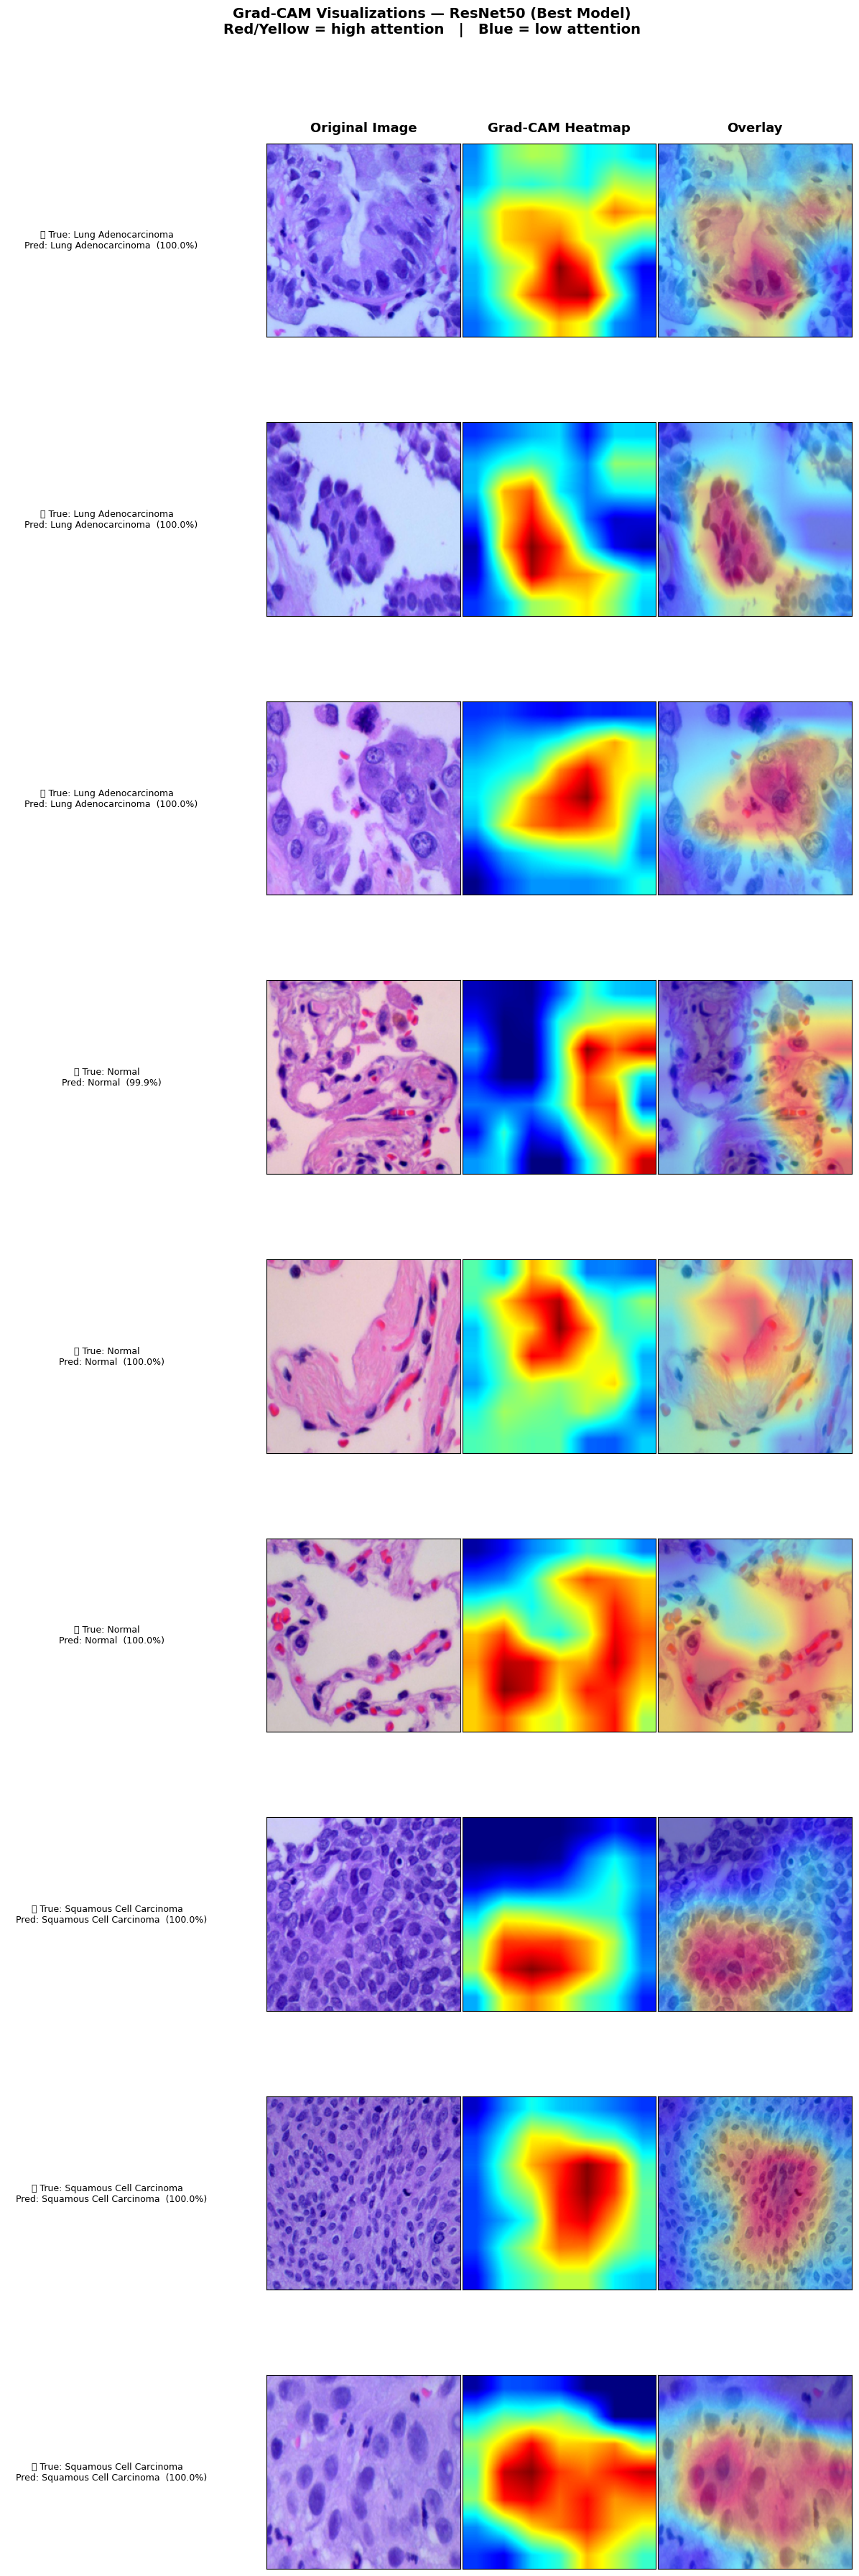

💾 Saved → results/gradcam_examples.png


In [13]:
# Layout: 9 rows (one per image) × 3 columns (original, heatmap, overlay)
n_total = len(CLASS_LABELS) * SAMPLES_PER_CLASS   # 9
fig, axes = plt.subplots(n_total, 3, figsize=(12, n_total * 4))

# Column headers
col_titles = ["Original Image", "Grad-CAM Heatmap", "Overlay"]
for col, title in enumerate(col_titles):
    axes[0, col].set_title(title, fontsize=13, fontweight="bold", pad=12)

row = 0

for cls_idx, (cls_label, cls_name) in enumerate(zip(CLASS_LABELS, CLASS_NAMES)):
    for img_path in sample_images[cls_label]:

        # ── Load image ────────────────────────────────────────────────────
        raw_img        = load_image_for_display(img_path)
        processed_img  = preprocess_for_resnet(raw_img)

        # ── Grad-CAM ──────────────────────────────────────────────────────
        heatmap, pred_idx, confidence = make_gradcam_heatmap(
            processed_img, feature_model, classifier_model,
            full_model=resnet_model,
            pred_index=None   # explain the predicted class
        )

        overlay, heatmap_colored = apply_heatmap_overlay(raw_img, heatmap)

        # ── Labels ────────────────────────────────────────────────────────
        true_name = cls_name
        pred_name = CLASS_NAMES[pred_idx]
        correct   = "✅" if pred_idx == cls_idx else "❌"
        row_title = (
            f"{correct} True: {true_name}\n"
            f"   Pred: {pred_name}  ({confidence*100:.1f}%)"
        )

        # ── Plot row ──────────────────────────────────────────────────────
        axes[row, 0].imshow(raw_img)
        axes[row, 0].set_ylabel(row_title, fontsize=9, rotation=0,
                                labelpad=160, va="center")

        axes[row, 1].imshow(heatmap_colored)

        axes[row, 2].imshow(overlay)

        # Remove axis ticks for cleaner look
        for col in range(3):
            axes[row, col].set_xticks([])
            axes[row, col].set_yticks([])

        row += 1

plt.suptitle(
    "Grad-CAM Visualizations — ResNet50 (Best Model)\n"
    "Red/Yellow = high attention   |   Blue = low attention",
    fontsize=14, fontweight="bold", y=1.01
)
plt.tight_layout()
plt.savefig("../results/gradcam_examples.png", dpi=150, bbox_inches="tight")
plt.show()
print("💾 Saved → results/gradcam_examples.png")

## Step 7 — Per-Class Grad-CAM Summary

We now generate one clean summary figure showing the average Grad-CAM
attention pattern per class — computed by averaging heatmaps across
all samples in each class.

**What this tells us:**
If the average heatmap consistently highlights the tissue center
(where pathological features appear) across all samples of a class,
it confirms the model has learned class-specific tissue patterns
rather than image-level artifacts.

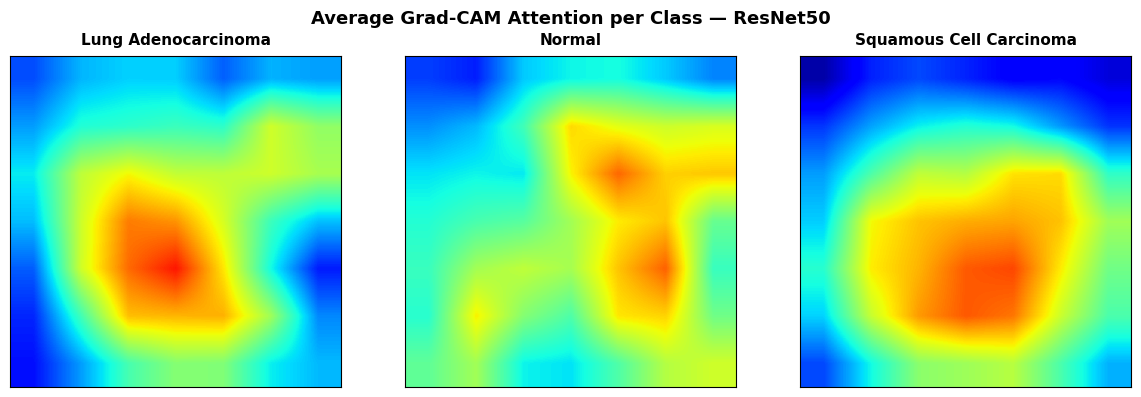

💾 Saved → results/gradcam_average_per_class.png


In [14]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

for col, (cls_label, cls_name) in enumerate(zip(CLASS_LABELS, CLASS_NAMES)):

    # Accumulate heatmaps for this class
    heatmaps = []
    for img_path in sample_images[cls_label]:
        raw_img       = load_image_for_display(img_path)
        processed_img = preprocess_for_resnet(raw_img)

        heatmap, _, _ = make_gradcam_heatmap(
            processed_img, feature_model, classifier_model,
            full_model=resnet_model,
        )
        # Resize to 224×224 before averaging so they're all the same size
        heatmap_resized = cv2.resize(heatmap, (224, 224))
        heatmaps.append(heatmap_resized)

    # Average heatmap across all samples for this class
    avg_heatmap = np.mean(heatmaps, axis=0)

    # Display as colormap only (no image overlay) to show pure attention pattern
    axes[col].imshow(avg_heatmap, cmap="jet", vmin=0, vmax=1)
    axes[col].set_title(cls_name, fontsize=11, fontweight="bold", pad=8)
    axes[col].set_xticks([])
    axes[col].set_yticks([])

plt.suptitle(
    "Average Grad-CAM Attention per Class — ResNet50",
    fontsize=13, fontweight="bold"
)
plt.tight_layout()
plt.savefig("../results/gradcam_average_per_class.png", dpi=150, bbox_inches="tight")
plt.show()
print("💾 Saved → results/gradcam_average_per_class.png")

## Summary

### Files saved to `results/`
| File | Contents |
|---|---|
| `gradcam_examples.png` | 9 images × 3 columns: original, heatmap, overlay |
| `gradcam_average_per_class.png` | Average attention map per class |

### What to look for when reviewing the visualizations

**Good signs — model is learning real pathology:**
- Heatmaps are centered on tissue regions, not image borders or corners
- Different classes show different attention patterns
  (adenocarcinoma vs squamous cell carcinoma should highlight different structures)
- High confidence predictions (>99%) show tight, focused heatmaps
- Correct predictions consistently show relevant tissue highlighted

**Warning signs — model may be using shortcuts:**
- Heatmaps concentrated in image corners or uniform backgrounds
- All classes showing identical attention patterns
- Low-confidence correct predictions with diffuse/scattered heatmaps

### What comes next — Phase 7: Gradio UI
With the best model identified (ResNet50) and its predictions
explainable via Grad-CAM, we build a web interface where a user can
upload any lung histopathology image and receive:
- The predicted class and confidence score
- A Grad-CAM overlay showing what the model focused on